In [2]:
import pandas as pd    #This is the most important library in data analysis — it handles tables of data.
import numpy as np    #loads NumPy, gives it shortcut np. Handles math, numbers, arrays.
import matplotlib.pyplot as plt  # loads the plotting library.
import seaborn as sns      # loads Seaborn, which makes prettier charts than Matplotlib with less code.

# Makes plots appear inside the notebook
%matplotlib inline    #this is a Jupyter magic command (starts with %). Tells Jupyter "show charts inside the notebook, not in a separate window."

plt.style.use('seaborn-v0_8')   #sets a clean visual style for all charts.
sns.set_palette("husl")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [6]:
# Cell 2: Load the dataset
df = pd.read_csv('data/sample_machine_data.csv') # short for DataFrame. This is what Pandas calls a table. Every data analyst in the world uses df as the variable name. It's convention.
                                                #reads a CSV file and converts it into a DataFrame.
# First look at the data
print("Shape:", df.shape)    #returns (rows, columns) — tells you how big your dataset is.
print("\nFirst 5 rows:")
df.head()   #shows the first 5 rows of the table. This is always the first thing you do when you load any dataset. Always.

Shape: (2839, 12)

First 5 rows:


,machine_id,shift_date,shift,planned_time_mins,actual_run_time_mins,good_units,total_units,downtime_mins,downtime_reason,availability,quality,oee
0,M01,2025-10-01,Day,480,451,725,839,29,Changeover,0.9396,0.8641,0.8119
1,M01,2025-10-01,Night,480,353,713,721,127,Material Shortage,0.7354,0.9889,0.7272
2,M02,2025-10-01,Day,480,396,776,785,84,Planned Maintenance,0.8250,0.9885,0.8155
3,M02,2025-10-01,Night,480,438,822,1074,42,Planned Maintenance,0.9125,0.7654,0.6984
4,M03,2025-10-01,Day,480,399,636,737,81,Mechanical Failure,0.8312,0.8630,0.7173


In [8]:
# Cell 3: Understand the dataset

print("=== SHAPE ===")
# df.shape returns (rows, columns) as a tuple
# [0] grabs the first value = rows, [1] grabs second = columns
print(f"Rows: {df.shape[0]:,}")   # :, adds comma formatting — 2839 becomes 2,839
print(f"Columns: {df.shape[1]}")

print("\n=== COLUMN NAMES & DATA TYPES ===")
# df.dtypes shows every column and its data type
# object   = text (strings)
# int64    = whole numbers
# float64  = decimal numbers
# datetime = dates (after conversion)
# IMPORTANT: you cannot do math on object columns — always check this first
print(df.dtypes)

print("\n=== MISSING VALUES ===")
# isnull() returns a True/False table — True means the value is missing
# .sum() counts all the Trues per column = total missing values
# Always check this BEFORE any analysis — missing data breaks things silently
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
# df.describe() — most powerful single line in Pandas
# For every numeric column it gives you:
# count  = how many non-missing values
# mean   = average
# std    = standard deviation (how spread out values are)
# min    = smallest value
# 25%    = 25th percentile (bottom quarter)
# 50%    = median (middle value)
# 75%    = 75th percentile (top quarter)
# max    = largest value
# .round(2) rounds everything to 2 decimal places for readability
df.describe().round(2)

=== SHAPE ===
Rows: 2,839
Columns: 12

=== COLUMN NAMES & DATA TYPES ===
machine_id                  str
shift_date                  str
shift                       str
planned_time_mins         int64
actual_run_time_mins      int64
good_units                int64
total_units               int64
downtime_mins             int64
downtime_reason             str
availability            float64
quality                 float64
oee                     float64
dtype: object

=== MISSING VALUES ===
machine_id                0
shift_date                0
shift                     0
planned_time_mins         0
actual_run_time_mins      0
good_units                0
total_units               0
downtime_mins             0
downtime_reason         208
availability              0
quality                   0
oee                       0
dtype: int64

=== BASIC STATISTICS ===


,planned_time_mins,actual_run_time_mins,good_units,total_units,downtime_mins,availability,quality,oee
count,2839.0,2839.00,2839.00,2839.00,2839.00,2839.00,2839.00,2839.00
mean,480.0,402.77,692.33,820.69,77.23,0.84,0.85,0.71
std,0.0,38.96,94.14,115.65,38.96,0.08,0.09,0.06
min,480.0,336.00,439.00,569.00,10.00,0.70,0.75,0.55
25%,480.0,368.00,625.00,734.00,43.00,0.77,0.75,0.67
50%,480.0,403.00,687.00,811.00,77.00,0.84,0.83,0.71
75%,480.0,437.00,756.00,905.00,112.00,0.91,0.93,0.75
max,480.0,470.00,1038.00,1138.00,144.00,0.98,0.99,0.89


In [9]:
# Cell 4: Clean the data

# pd.to_datetime() converts text dates like "2024-01-15" into real date objects
# Once converted, Python understands it as a date — you can extract month, year, 
# compare dates, sort by date. You CANNOT do any of this with plain text (object type)
df['shift_date'] = pd.to_datetime(df['shift_date'])

# df['column_name'] — this is how you select a single column from a DataFrame
# fillna() replaces every NaN (missing/empty value) with whatever you put inside
# Here: missing downtime_reason means machine was running fine — so we label it
df['downtime_reason'] = df['downtime_reason'].fillna('No Downtime')

# Creating a NEW column by assigning to df['new_column_name']
# .dt is a special accessor for date columns — unlocks date functions
# .dt.month_name() extracts the month name: "January", "February" etc.
df['month'] = df['shift_date'].dt.month_name()

# .dt.month extracts month as a NUMBER (1, 2, 3...)
# We need this because "January" sorts alphabetically — 1 sorts correctly
df['month_num'] = df['shift_date'].dt.month

# value_counts() — counts how many times each unique value appears in a column
# One of the most used functions in Pandas — you will use this every single day
print("=== AFTER CLEANING ===")
print(f"shift_date type: {df['shift_date'].dtype}")
# .dtype — tells you the data type of a column

print(f"\nMissing values remaining:")
print(df.isnull().sum())
# isnull() returns True/False for every cell
# .sum() counts all the Trues = total missing values per column

print(f"\nDate range: {df['shift_date'].min()} to {df['shift_date'].max()}")
# .min() and .max() on a date column give you the earliest and latest date

print(f"\nDowntime reasons:")
print(df['downtime_reason'].value_counts())
# Shows every unique downtime reason and how many times it occurred

=== AFTER CLEANING ===
shift_date type: datetime64[us]

Missing values remaining:
machine_id              0
shift_date              0
shift                   0
planned_time_mins       0
actual_run_time_mins    0
good_units              0
total_units             0
downtime_mins           0
downtime_reason         0
availability            0
quality                 0
oee                     0
month                   0
month_num               0
dtype: int64

Date range: 2025-10-01 00:00:00 to 2026-03-31 00:00:00

Downtime reasons:
downtime_reason
Mechanical Failure     573
Planned Maintenance    501
Changeover             458
Material Shortage      351
Electrical Fault       279
Operator Break         260
Quality Check Hold     209
No Downtime            208
Name: count, dtype: int64


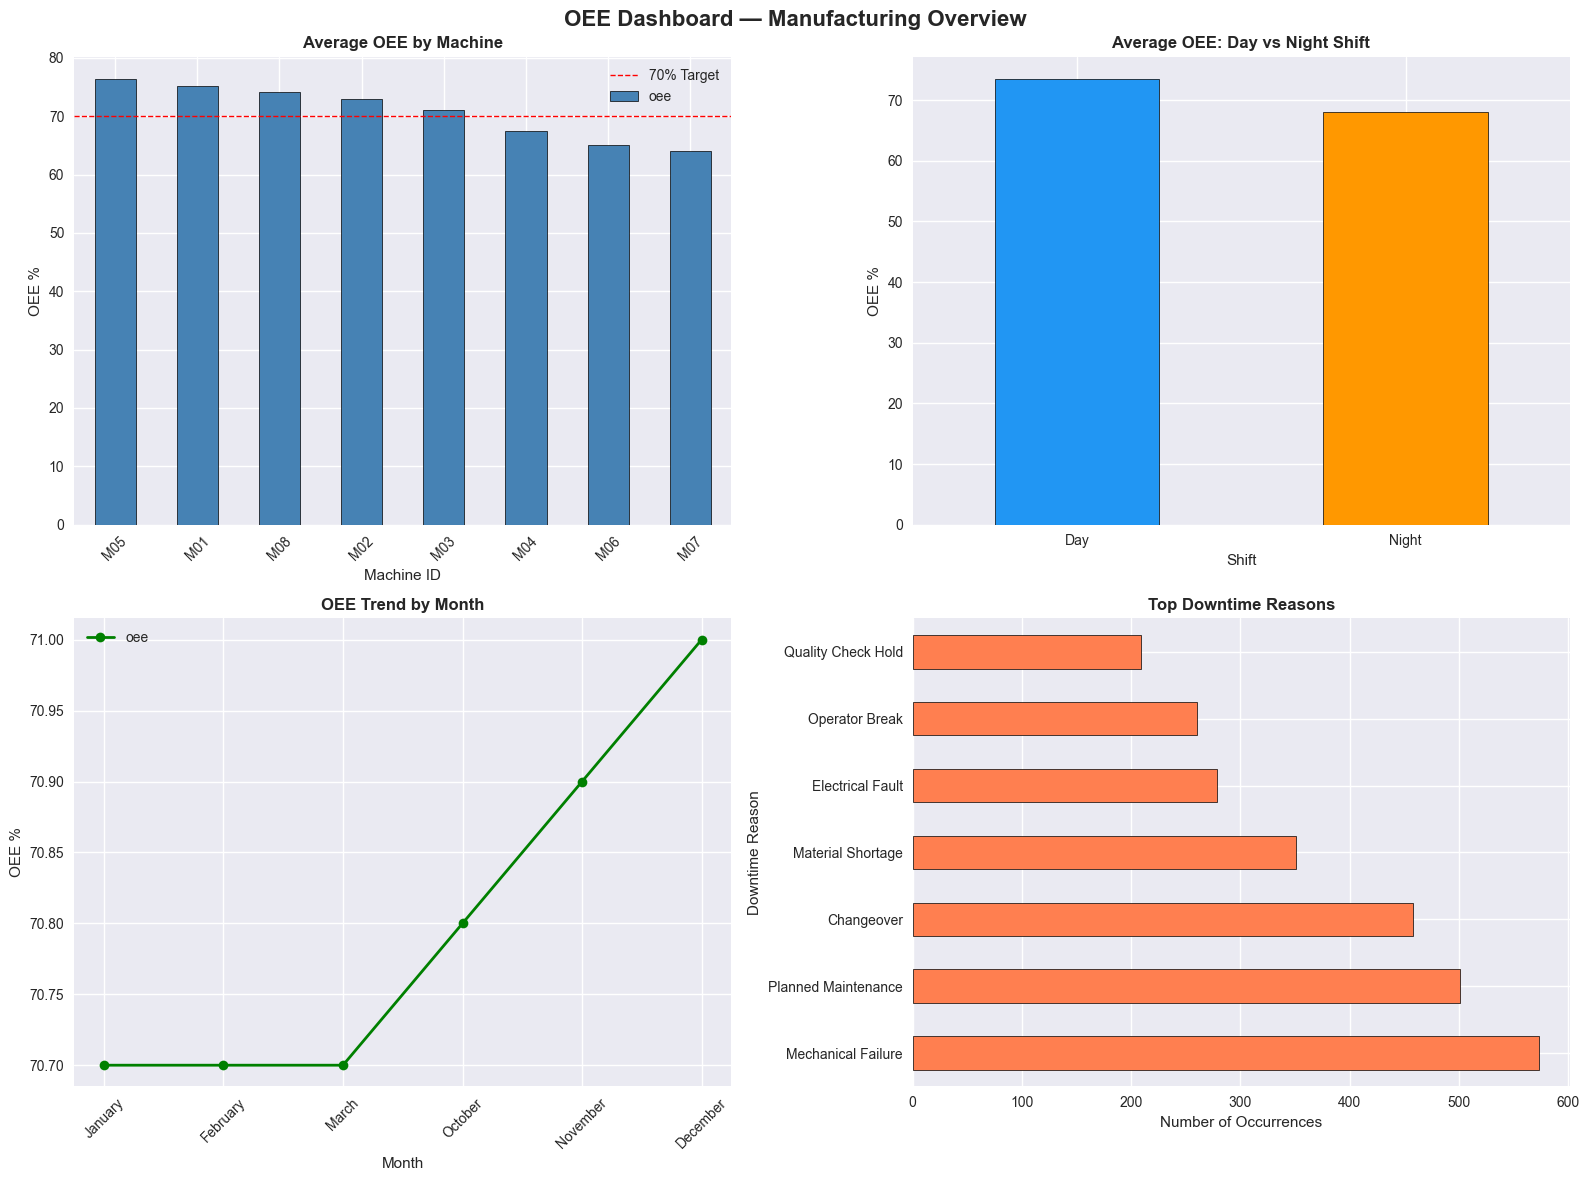

Charts saved to data/oee_overview.png


In [10]:
# Cell 5: OEE Overview Charts

# fig, axes creates a FIGURE with multiple SUBPLOTS inside it
# figsize=(16, 12) sets the size — width=16 inches, height=12 inches
# (2, 2) means 2 rows, 2 columns = 4 charts in one figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# fig.suptitle adds ONE big title above all charts
# fontsize=16, fontweight='bold' — styling
fig.suptitle('OEE Dashboard — Manufacturing Overview', fontsize=16, fontweight='bold')

# ============================================================
# CHART 1: Average OEE by Machine (top left)
# axes[0,0] means row 0, column 0 = top left chart
# ============================================================

# groupby('machine_id') — groups all rows by machine
# ['oee'] — we only care about the oee column
# .mean() — calculate average oee per machine
# .sort_values() — sort from highest to lowest
# .mul(100) — multiply by 100 to convert 0.73 → 73%
# .round(1) — round to 1 decimal place
oee_by_machine = df.groupby('machine_id')['oee'].mean().mul(100).round(1).sort_values(ascending=False)

# .plot(kind='bar') — bar chart
# ax=axes[0,0] — draw on top left subplot
# color='steelblue' — bar colour
# edgecolor='black' — outline colour
# linewidth=0.5 — outline thickness
oee_by_machine.plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='black', linewidth=0.5)

# Chart labels and formatting
axes[0,0].set_title('Average OEE by Machine', fontweight='bold')
axes[0,0].set_xlabel('Machine ID')
axes[0,0].set_ylabel('OEE %')
axes[0,0].tick_params(axis='x', rotation=45)  # rotate x labels 45 degrees so they don't overlap
axes[0,0].axhline(y=70, color='red', linestyle='--', linewidth=1, label='70% Target')
# axhline draws a HORIZONTAL LINE across the chart
# y=70 — at the 70% mark
# linestyle='--' — dashed line
# This is your target line — machines below it need attention
axes[0,0].legend()  # shows the label we set above

# ============================================================
# CHART 2: Day vs Night Shift OEE (top right)
# axes[0,1] means row 0, column 1 = top right chart
# ============================================================

# groupby('shift') groups by Day/Night
oee_by_shift = df.groupby('shift')['oee'].mean().mul(100).round(1)
oee_by_shift.plot(kind='bar', ax=axes[0,1], color=['#2196F3', '#FF9800'], edgecolor='black', linewidth=0.5)
# ['#2196F3', '#FF9800'] — hex color codes, blue for Day, orange for Night
axes[0,1].set_title('Average OEE: Day vs Night Shift', fontweight='bold')
axes[0,1].set_xlabel('Shift')
axes[0,1].set_ylabel('OEE %')
axes[0,1].tick_params(axis='x', rotation=0)  # no rotation needed — only 2 bars

# ============================================================
# CHART 3: OEE Trend by Month (bottom left)
# axes[1,0] means row 1, column 0 = bottom left chart
# ============================================================

# sort_values('month_num') — sort by month NUMBER (1,2,3) not name (alphabetical)
# This is why we created month_num in Cell 4
oee_by_month = df.groupby(['month', 'month_num'])['oee'].mean().mul(100).round(1)
oee_by_month = oee_by_month.reset_index().sort_values('month_num')
# reset_index() — after groupby, month becomes the index
# We reset it back to a regular column so we can sort by month_num

oee_by_month.plot(x='month', y='oee', kind='line', ax=axes[1,0],
                  color='green', marker='o', linewidth=2)
# kind='line' — line chart instead of bar
# marker='o' — adds a dot at each data point
axes[1,0].set_title('OEE Trend by Month', fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('OEE %')
axes[1,0].tick_params(axis='x', rotation=45)

# ============================================================
# CHART 4: Downtime Reasons (bottom right)
# axes[1,1] means row 1, column 1 = bottom right chart
# ============================================================

# value_counts() counts occurrences of each downtime reason
# drop 'No Downtime' — we only want actual downtime causes
downtime = df[df['downtime_reason'] != 'No Downtime']['downtime_reason'].value_counts()
# df[df['column'] != 'value'] — this is FILTERING
# Keep only rows where downtime_reason is NOT 'No Downtime'

downtime.plot(kind='barh', ax=axes[1,1], color='coral', edgecolor='black', linewidth=0.5)
# kind='barh' — horizontal bar chart (better for category names)
axes[1,1].set_title('Top Downtime Reasons', fontweight='bold')
axes[1,1].set_xlabel('Number of Occurrences')
axes[1,1].set_ylabel('Downtime Reason')

# plt.tight_layout() — automatically adjusts spacing so charts don't overlap
plt.tight_layout()
plt.savefig('data/oee_overview.png', dpi=150, bbox_inches='tight')
# savefig() saves the chart as an image file
# dpi=150 — resolution (higher = sharper)
# bbox_inches='tight' — no whitespace around edges
plt.show()
print("Charts saved to data/oee_overview.png")